# Koduppgift 9 - Kapitel 8: Förtränade modeller och Streamlit-applikation

I denna uppgift utgår vi ifrån kodexempel 2 i detta kapitel.

**Uppgiften består av två delar:**

a) Ta egna bilder som du predikterar med en förtränad modell.

b) Bygg en applikation (med exempelvis Streamlit) som använder en förtränad modell för att prediktera bilder. Hur du designar applikationen och vilken funktionalitet du inkluderar väljer du själv.

**Förtränade modeller:**
- ResNet50: CNN-arkitektur med cirka 26 miljoner parametrar, tränad på ImageNet (1000 klasser)
- Dokumentation: https://keras.io/api/applications/
- ImageNet klasser: https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

## Importera bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import os
import streamlit as st

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.1
Keras version: 3.11.3


# Del A: Prediktera egna bilder med förtränad modell

## Ladda förtränad ResNet50 modell

In [2]:
# Ladda förtränad ResNet50 modell
# Modellen är tränad på ImageNet med 1000 olika klasser
model = ResNet50(weights='imagenet')

print("ResNet50 modell laddad!")
print(f"Modellen kan klassificera 1000 olika klasser från ImageNet.")
print(f"Input-storlek: 224x224 pixlar med 3 kanaler (RGB)")

ResNet50 modell laddad!
Modellen kan klassificera 1000 olika klasser från ImageNet.
Input-storlek: 224x224 pixlar med 3 kanaler (RGB)


## Funktion för att prediktera bilder

In [3]:
def predict_image(image_path, model, top_n=5):
    """
    Prediktera en bild med förtränad ResNet50 modell.
    
    Args:
        image_path: Sökväg till bildfilen
        model: Förtränad modell (ResNet50)
        top_n: Antal topprediktioner att visa (standard: 5)
    
    Returns:
        predictions: Lista med topprediktioner
        preprocessed_img: Förbearbetad bild för visualisering
    """
    # Ladda och förbehandla bilden
    img = image.load_img(image_path, target_size=(224, 224))
    
    # Konvertera till array
    img_array = image.img_to_array(img)
    
    # Expandera dimensioner för batch (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Förbehandla bilden för ResNet50
    img_preprocessed = preprocess_input(img_batch)
    
    # Prediktera
    predictions = model.predict(img_preprocessed, verbose=0)
    
    # Dekodera prediktioner till läsbara klasser
    decoded_predictions = decode_predictions(predictions, top=top_n)[0]
    
    return decoded_predictions, img

print("Predict-funktion definierad!")

Predict-funktion definierad!


## Prediktera egna bilder

Lägg dina egna bilder i samma mapp som denna notebook, eller ange sökvägen till bilderna.

**Tips:**
- Ta bilder med din mobil eller kamera
- Bilderna kan vara i format JPG, PNG, JPEG
- För bästa resultat: välj bilder på objekt som finns i ImageNet (1000 klasser)
- Exempel: djur, fordon, mat, elektronik, möbler, etc.

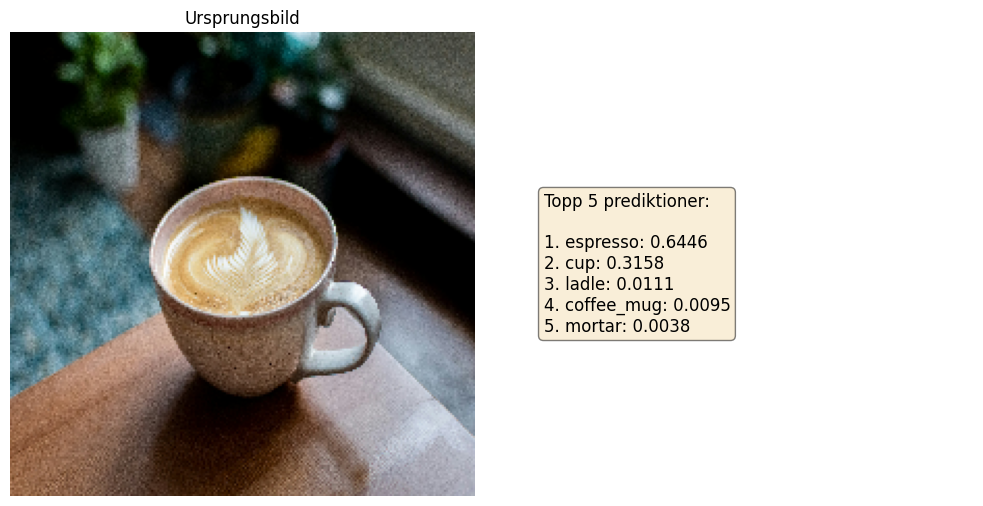


Prediktioner för bilder\coffe.jpg:
------------------------------------------------------------
1. espresso: 0.6446 (64.46%)
2. cup: 0.3158 (31.58%)
3. ladle: 0.0111 (1.11%)
4. coffee_mug: 0.0095 (0.95%)
5. mortar: 0.0038 (0.38%)


In [4]:
# Exempel: Prediktera en bild
# Ändra sökvägen till din egen bild
# Använd os.path.join() för korrekt sökvägshantering (fungerar på alla operativsystem)
image_path = os.path.join('bilder', 'coffe.jpg')  # Relativ sökväg från notebookens position

# Alternativ: Använd raw string (r'...') om du behöver absolut sökväg
# image_path = r'studymodules\NBI Handlesakademin\AI - teori och tillämpning\del2\Kursvecka2\koduppgift\9\bilder\coffe.jpg'

# Alternativ: Använd forward slashes (fungerar på både Windows och Mac/Linux)
# image_path = 'bilder/coffe.jpg'

# Kontrollera om filen finns
if os.path.exists(image_path):
    # Prediktera
    predictions, img = predict_image(image_path, model, top_n=5)
    
    # Visa bilden
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Ursprungsbild')
    
    # Visa topprediktioner
    plt.subplot(1, 2, 2)
    plt.axis('off')
    prediction_text = '\n'.join([
        f"{i+1}. {pred[1]}: {pred[2]:.4f}" 
        for i, pred in enumerate(predictions)
    ])
    plt.text(0.1, 0.5, f"Topp 5 prediktioner:\n\n{prediction_text}", 
             fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Skriv ut prediktioner
    print(f"\nPrediktioner för {image_path}:")
    print("-" * 60)
    for i, (imagenet_id, label, score) in enumerate(predictions, 1):
        print(f"{i}. {label}: {score:.4f} ({score*100:.2f}%)")
else:
    print(f"Bildfilen '{image_path}' hittades inte.")
    print("Lägg din bild i samma mapp som denna notebook eller ange rätt sökväg.")

1/1 - 1s - 1s/step

bilder\coffe.jpg:
  1. espresso: 0.6446 (64.46%)
  2. cup: 0.3158 (31.58%)
  3. ladle: 0.0111 (1.11%)

bilder\dog.jpg:
  1. soft-coated_wheaten_terrier: 0.3531 (35.31%)
  2. Lakeland_terrier: 0.2218 (22.18%)
  3. wire-haired_fox_terrier: 0.1139 (11.39%)

bilder\car.jpg:
  1. minivan: 0.6904 (69.04%)
  2. minibus: 0.1098 (10.98%)
  3. trailer_truck: 0.0804 (8.04%)


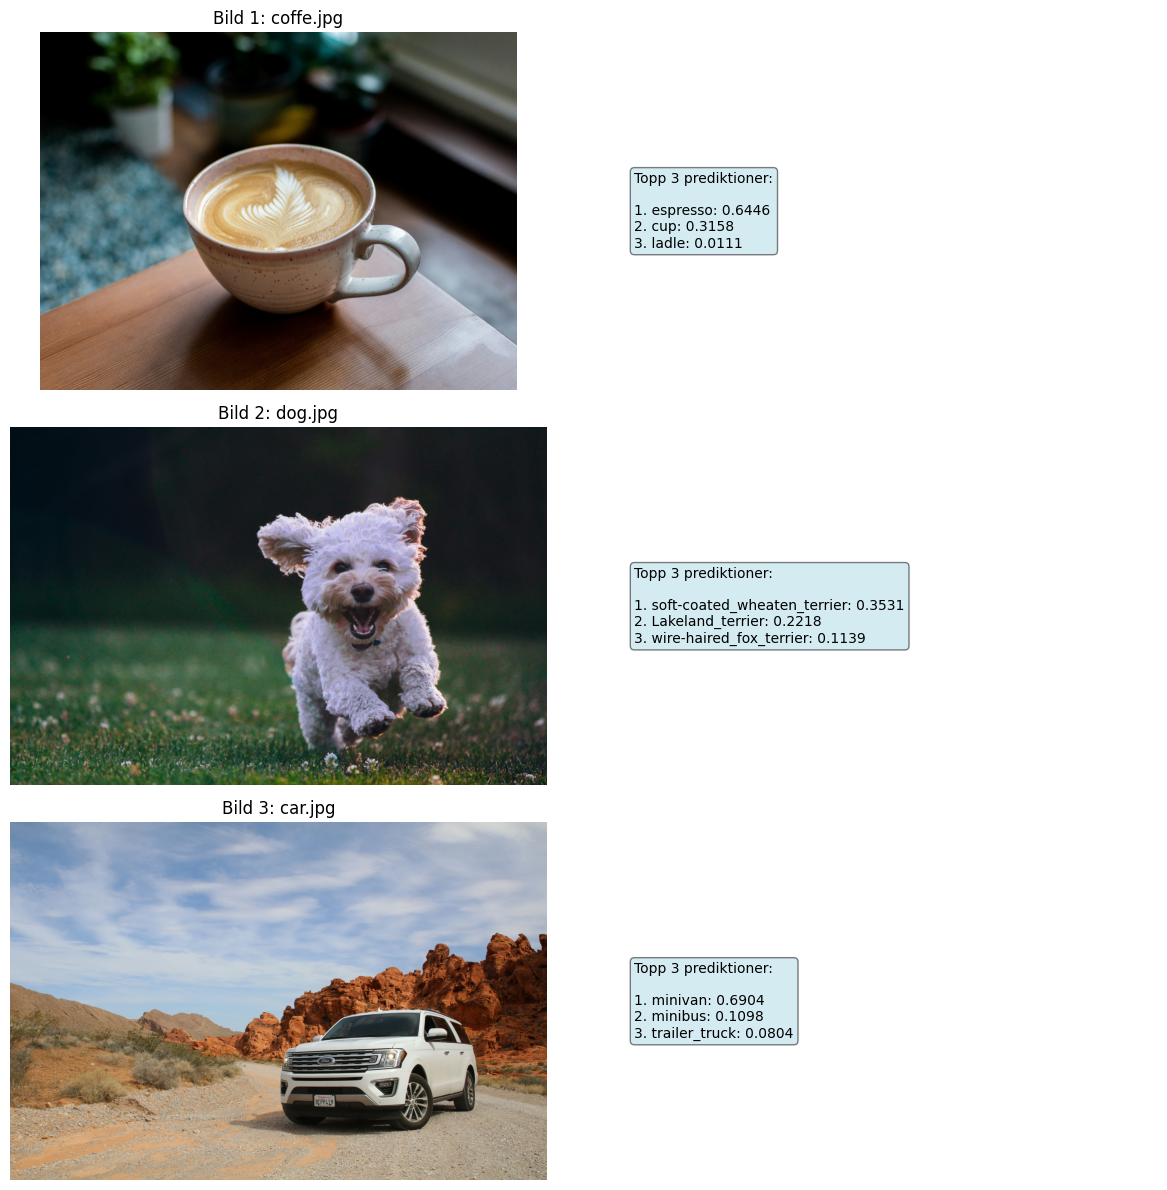

In [5]:
# Prediktera flera bilder samtidigt
# Använd os.path.join() för att bygga sökvägar korrekt
image_paths = [
    os.path.join('bilder', 'coffe.jpg'),
    os.path.join('bilder', 'dog.jpg'),
    os.path.join('bilder', 'car.jpg')
]  # Ändra till dina bilder i bilder-mappen

# Filtrera bort bilder som inte finns
existing_images = [path for path in image_paths if os.path.exists(path)]

if existing_images:
    # Ladda och förbehandla alla bilder
    imgs = []
    for path in existing_images:
        img = image.load_img(path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)
        img_preprocessed = preprocess_input(img_batch)
        imgs.append(img_preprocessed)
    
    # Stacka alla bilder till en batch
    batch = np.vstack(imgs)
    
    # Prediktera batch
    predictions = model.predict(batch, verbose=2)
    
    # Visa resultat för varje bild
    num_images = len(existing_images)
    fig, axes = plt.subplots(num_images, 2, figsize=(12, 4*num_images))
    
    if num_images == 1:
        axes = axes.reshape(1, -1)
    
    for i, path in enumerate(existing_images):
        # Ladda originalbild för visning
        img = image.load_img(path)
        
        # Dekodera prediktioner
        decoded = decode_predictions(predictions[i:i+1], top=3)[0]
        
        # Visa bild
        axes[i, 0].imshow(img)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'Bild {i+1}: {os.path.basename(path)}')
        
        # Visa topp 3 prediktioner
        axes[i, 1].axis('off')
        prediction_text = '\n'.join([
            f"{j+1}. {pred[1]}: {pred[2]:.4f}" 
            for j, pred in enumerate(decoded)
        ])
        axes[i, 1].text(0.1, 0.5, f"Topp 3 prediktioner:\n\n{prediction_text}", 
                        fontsize=10, verticalalignment='center',
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # Skriv ut i konsolen
        print(f"\n{path}:")
        for j, (_, label, score) in enumerate(decoded, 1):
            print(f"  {j}. {label}: {score:.4f} ({score*100:.2f}%)")
    
    plt.tight_layout()
    plt.show()
else:
    print("Inga bilder hittades. Kontrollera sökvägarna.")

# Del B: Bygg Streamlit-applikation

Vi skapar en avancerad Streamlit-applikation där användare kan ladda upp bilder och få prediktioner från förtränad modell.

 **Kör applikationen:**
   ```bash
   python -m streamlit run image_classifier_app.py

## Var kan man hitta bilder att testa med?



Här är några bra källor för att hitta bilder att testa med applikationen:

### 1. **Egna bilder**
- Ta bilder med din mobil eller kamera
- Bilderna kan vara på djur, fordon, mat, elektronik, möbler, etc.
- Spara bilderna i format PNG, JPG eller JPEG

### 2. **Unsplash** (Gratis, hög kvalitet)
- URL: https://unsplash.com/
- Gratis bilder med hög kvalitet
- Sök efter objekt som finns i ImageNet (hundar, katter, bilar, etc.)
- Exempel: https://unsplash.com/s/photos/dog, https://unsplash.com/s/photos/car


### 3. **ImageNet** (För testbilder)
- URL: https://www.image-net.org/
- Det dataset som ResNet50 tränades på
- Du kan hitta exempelbilder för olika klasser
- Lista över alla klasser: https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

...


### Tips för bästa resultat:
- Använd tydliga bilder med bra belysning
- Objektet ska vara i fokus och tydligt synligt
- Försök att ha objektet i mitten av bilden
- Bilderna kan vara i olika storlekar - appen ändrar automatiskt till 224x224
- Testa med olika typer av objekt för att se modellens förmåga